# Experiment #5: Comparison LLMS

In this experiment, we compare the performance of different Taxonomies created by LLMs on the task of generating recommendations and the similarity of the generated Taxonomies. We going to use as a recommendation Model the KGIL model from the first experiment. For a neat evaluation, we will use the amazon-video_games dataset. It has more items than the other datasets, so the LLMs have more information to generate the Taxonomies. We assume that this will help the LLMs to a wider range of variations of the Taxonomies and be more challenging for the approach.

**Data**: We use the amazon-video_games dataset. Since LLMs are computationally expensive, we use a smaller subset of the dataset for the LLMs. We use a 20-core subset of the dataset.

**Models**: We use the following LLMs:
+ Llama3.2-3b: _In experiment #1 we presented our approach to generate Taxonomies from text using Keyword Extraction Model and LLMs. As baseline LLM we used the open weightLlama3.2-3b Model. It is the small version of the LLama3.2 family with a footprint of roughly 2 GB which makes it the smallest LLMs in the experiment
+ ChatGPT-4: _This model was used in different studies, showed very promising results in the generation of Taxonomies [1](https://arxiv.org/pdf/2402.07386), [2](https://arxiv.org/pdf/2403.12173). It was able to outperform classic approaches and other state-of-the-art LLMs. [[3]](https://arxiv.org/pdf/2503.21810)_ 
+ DeepSeek-R1: _This open weight showed in the comparsion stduy [[3]](https://arxiv.org/pdf/2503.21810) of LLMs integrated in Embedding Models to generate taxonomies on tabular data promising results. On one dataset itwas able to generate a taxonomy the highest RI and Purity. It has a footprint of 4.7 GB_ 
+ Qwen2.5-7B: _Additionally we explore the effectiveness of the Qwen2.5-Modell with 7B parameters. In the comparsion study [[3]](https://arxiv.org/pdf/2503.21810) the model family with 14B and 32B parameters achieved good results, while trailing to the GPT-4 and DeepSeek-R1, for taxnomies on tabular data. It has a footprint of 4.7 GB_ 

**Metrics**: We use the following metrics:
- Quantitative: 
+ Performance and cost: We use the same performance and cost metrics as in the first experiment.
+ Similarity: As qualitative metric we use the `levenshtein distance` and `cosine similarity` to measure the similarity of the generated Taxonomies.

- Qualitative:
+ Error analysis: We conduct an error analysis on the KGIL model for each generated Taxonomy. This will help identify if the taxonomies are useful during the multi-hop reasoning of the KGIL model. Also it help identify if KGIL systematically predicts errors for certain entities.

All the metrics help identify the best performing LLM for the task of generating Taxonomies and how to improve the performance of the LLM taxonomie genration process for Graph Neural Network Knowledge Graph Recommender Systems.

**Infrastructure:**
The experiments were conducted on a Apple M2 MacBook Pro with 16GB RAM and 10-core CPU.

## .0 Setup

In [1]:
import os # path management
import sys # system path management
import pandas as pd # data manipulation
import numpy as np # data manipulation
from scipy.sparse import csr_matrix # build adjency matrix
import random # random number generation
import torch # for gnn
import networkx as nx # graph library
from sentence_transformers import SentenceTransformer # 
from time import time # time measurement


sys.path.append('../..')  # Add the project root to the path so we can import from utils

from utils.data_processing import Build_KG, KG_Filter

from models.KGIL.utils.metrics import (
    gini_coefficient, 
    cosine_similarity_matrices
)


In [2]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

MODEL_TECHNIQUE = "gemma3"

EXPERIMENT_NAME = "#5"
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

EPOCH = "120" # set epochs small, because the dataset is large
BATCH_SIZE = "512" # set batch size high, because the dataset is large
TEST_BATCH_SIZE = "512"

No self-loops found in the taxonomy.
No item-to-grandchild redundant relationships (item -> child -> grandchild pattern) found.
Original relations DataFrame size: 128683
Filtered relations DataFrame size: 128683
Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/Keyword Batch size/amazon-Video_Games/gemma3/10
Combined KG has 264763 unique triples.
Found 24020 unique entities.
Found 3 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 128683 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/Keyword Batch size/amazon-Video_Games/gemma3/10/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/Keyword Batch size/amazon-Video_Games/gemma3/10/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/Keyword

100%|##########| 3990/3990 [00:00<00:00, 1637181.86it/s]



Begin to load knowledge graph triples ...


100%|##########| 97926/97926 [00:02<00:00, 36817.37it/s]


End to build graph ... MultiDiGraph with 19143 nodes and 97926 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

100%|##########| 97926/97926 [00:03<00:00, 26610.70it/s] 


End to build graph ... MultiDiGraph with 19143 nodes and 97926 edges
building the adj mat ...
Begin to build sparse relation matrix ...


100%|██████████| 5/5 [00:00<00:00, 181.41it/s]


Density of the graph: 0.0002672395328631352
Average degree of the graph: 10.230998276132267
Max degree of the graph: 22810
Dataset statistics:
Number of training interactions: 3990
Number of test interactions: 813
Number of users: 4047
Number of items: 23878
Batch size: 512
start training ...

Epoch 1/120
Number of iterations expected: 7
Processing 3990 samples in batches of 512

First batch statistics:
Users shape: torch.Size([512])
Positive items shape: torch.Size([512])
Negative items shape: torch.Size([512])

Iteration 0 losses:
rec_loss: 0.501357
inv_mean: 3.147671
inv_var: 0.002460
outer_loss: 0.532859

Gradient norms:
all_embed: 2.335345
latent_emb: 0.000070
gcn.weight: 0.403494
gcn.disen_weight_att: 0.000731
gcn.invariant_generator.kg_W_r: 0.000004
augmenter.edge_mlp_list.0.0.weight: 0.000016
augmenter.edge_mlp_list.0.0.bias: 0.000012
augmenter.edge_mlp_list.0.2.weight: 0.000007
augmenter.edge_mlp_list.0.2.bias: 0.000010
augmenter.edge_mlp_list.1.0.weight: 0.000024
augmenter.ed

OSError: [Errno 28] No space left on device: '/Users/U725801/Documents/GitHub/Masterarbeit-Playground/src/experiments/#5 Keyword Batch size /mlruns/877573842248256496/36ee18d5de0c46afbb8d8307dc099801/meta.yaml'

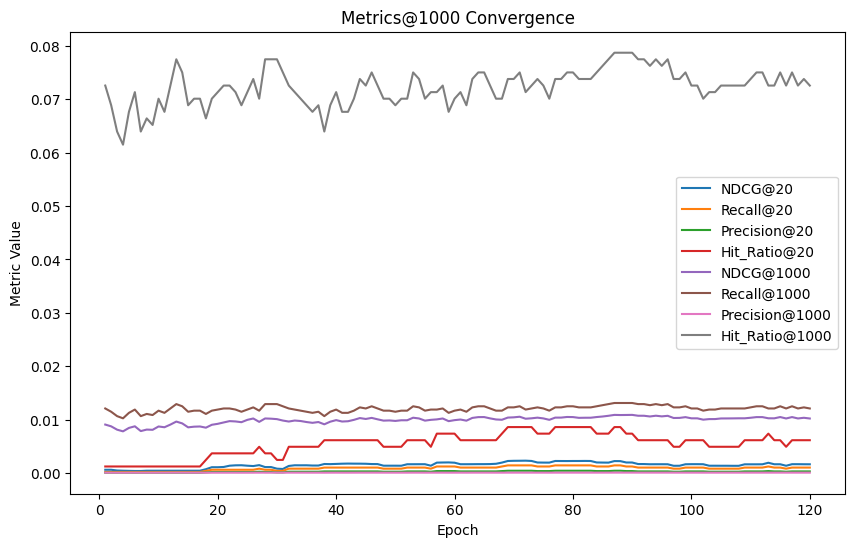

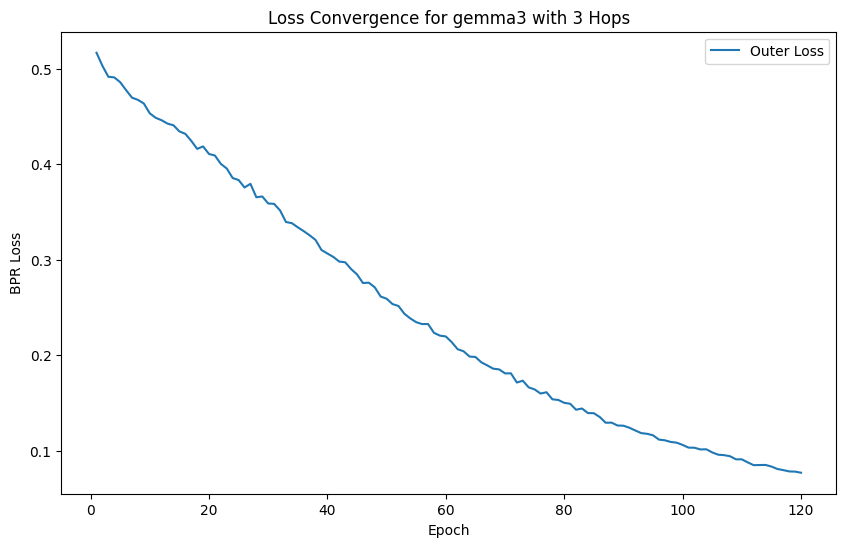

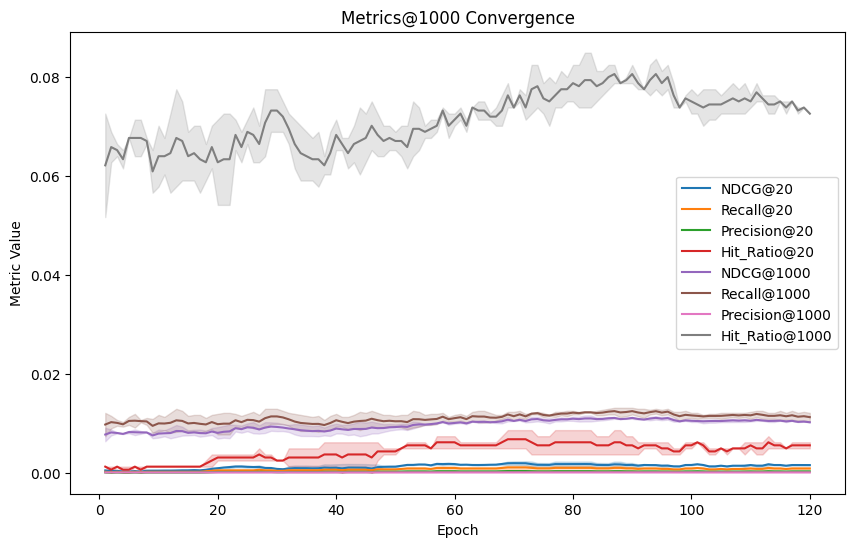

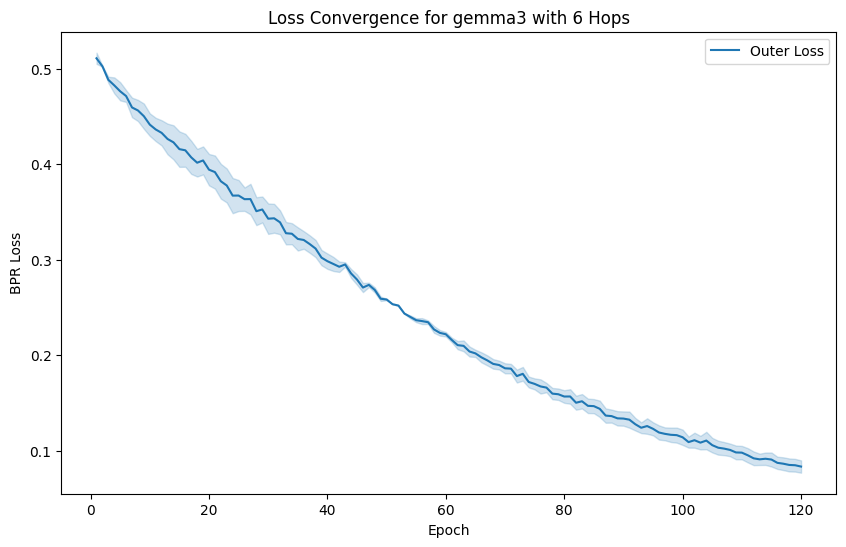

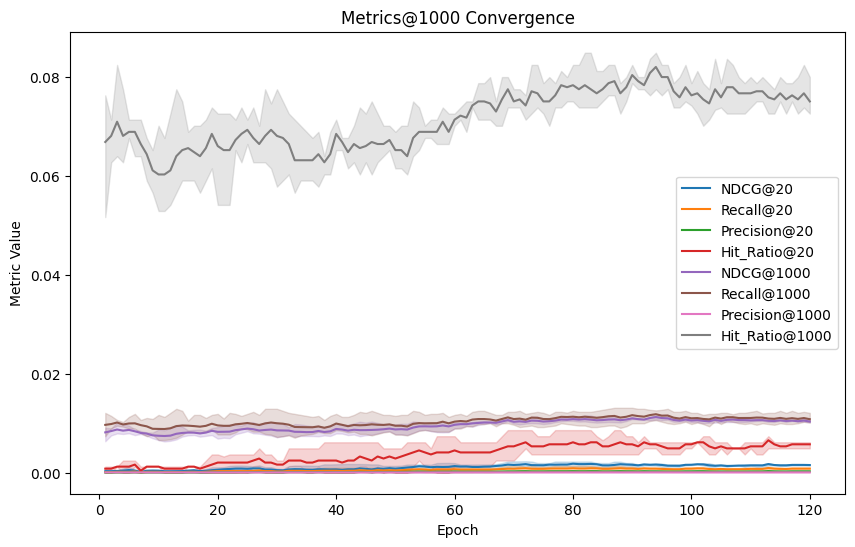

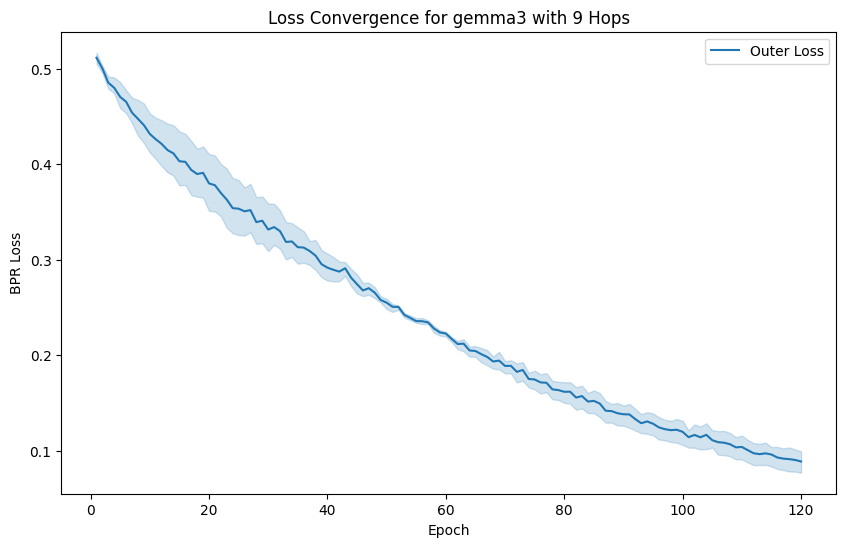

In [15]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender
import seaborn as sns
import matplotlib.pyplot as plt
# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--lr', "1e-3"])



n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0



def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict

def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    import mlflow
    EXPERIMENT_NAME = "Keyword Batch size"
    MLFLOW_EXPERIMENT_NAME = "Keyword Batch size"
    BATCH_SIZES = [5,10,15]
    BATCH_SIZES = [10,15]
    df_metric_convergence = pd.DataFrame()
    df_outer_loss = pd.DataFrame()

    mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
    # Capture the base sys.argv configuration set by "Dynamic Argument Setting"
    # This will be used to reset sys.argv for each run iteration.
    base_argv_config_for_runs = sys.argv.copy()
    for batch_size in BATCH_SIZES:
            for N_CONTEXT_HOPS in [3,6,9,11]:

                with mlflow.start_run(run_name=f"{DATASET}--{batch_size}-Batch-Size"):
                    
                    # Load relations
                    MODEL_TECHNIQUE = "gemma3"
                    EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE,str(batch_size))

                    triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
                    gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy_batchsize_{batch_size}.csv')
                    #gemma_triplet_df = KG_Filter().filter_item_to_grandchild_redundancy(gemma_triplet_df)

                    # without grandparent use function 
                    
                    data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
                    metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
                    train_df = pd.read_csv(data_path+'/train_df.csv')
                    test_df = pd.read_csv(data_path+'/test_df.csv')
                    build_kg = Build_KG()
                    train_df = build_kg.user_item_triples(train_df)
                    test_df = build_kg.user_item_triples(test_df)
                    kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(gemma_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)
                
                    

                    seed = 2020
                    
                    # --- Corrected sys.argv setup for parse_args ---
                    # Prepare the argument list for this specific run
                    run_specific_argv = base_argv_config_for_runs.copy()
                    run_specific_argv.extend(['--context_hops', str(N_CONTEXT_HOPS)])
                    
                    # Backup global sys.argv and set it for parse_args
                    original_sys_argv_snapshot = sys.argv # Save the actual current sys.argv
                    sys.argv = run_specific_argv # Temporarily override for parse_args
                    
                    print(sys.argv) # Existing print line, will show run_specific_argv
                    
                    random.seed(seed)
                    np.random.seed(seed)
                    torch.manual_seed(seed)
                    torch.cuda.manual_seed_all(seed)
                    torch.backends.cudnn.deterministic = True
                    torch.backends.cudnn.benchmark = False

                    """read args"""
                    global args, device
                    args = parse_args() # Uses the temporarily set sys.argv
                    
                    # Restore global sys.argv immediately after parse_args
                    sys.argv = original_sys_argv_snapshot
                    # --- End of sys.argv correction block ---

                    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

                    """build dataset"""
                    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
                    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

                    gemma_density = nx.density(graph)
                    print(f"Density of the graph: {gemma_density}")
                    gemma_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
                    print(f"Average degree of the graph: {gemma_avg_degree}")
                    gemma_max_degree = max(dict(nx.degree(graph)).values())
                    print(f"Max degree of the graph: {gemma_max_degree}")

                    print(f"Dataset statistics:")
                    print(f"Number of training interactions: {len(train_cf)}")
                    print(f"Number of test interactions: {len(test_cf)}")
                    print(f"Number of users: {n_params['n_users']}")
                    print(f"Number of items: {n_params['n_items']}")
                    print(f"Batch size: {args.batch_size}")

                    n_users = n_params['n_users']
                    n_items = n_params['n_items']
                    n_entities = n_params['n_entities']
                    n_relations = n_params['n_relations']
                    n_nodes = n_params['n_nodes']
                    
                    """cf data"""
                    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
                    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

                    """define model"""
                    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
                    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
                    
                    """define optimizer"""
                    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
                    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
                    model.augmenter = augmenter

                    cur_best_pre_0 = 0
                    stopping_step = 0
                    should_stop = False
                    total_iter = max(len(train_cf) // args.batch_size, 1)
                    get_print = max(total_iter // 20, 1)
                    
                    print("start training ...")
                    for epoch in range(args.epoch):
                        # Add epoch start print
                        print(f"\nEpoch {epoch+1}/{args.epoch}")
                        print(f"Number of iterations expected: {total_iter}")
                        
                        index = np.arange(len(train_cf))
                        np.random.shuffle(index)
                        model.train()

                        train_cf_pairs = train_cf_pairs[index]
                        total_outer_loss, total_inner_loss, s = 0, 0, 0
                        train_s_t = time()
                        iteration = 0
                        
                        # Add batch processing print
                        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
                        
                        while s + args.batch_size <= len(train_cf):
                            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
                            
                            # Debug print for first batch of first epoch
                            if epoch == 0 and iteration == 0:
                                print("\nFirst batch statistics:")
                                print(f"Users shape: {batch['users'].shape}")
                                print(f"Positive items shape: {batch['pos_items'].shape}")
                                print(f"Negative items shape: {batch['neg_items'].shape}")
                            
                            rec_loss, inv_mean, inv_var = model(batch)
                            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
                            
                            # Debug print losses
                            if iteration % 100 == 0:
                                print(f"\nIteration {iteration} losses:")
                                print(f"rec_loss: {rec_loss.item():.6f}")
                                print(f"inv_mean: {inv_mean.item():.6f}")
                                print(f"inv_var: {inv_var.item():.6f}")
                                print(f"outer_loss: {outer_loss.item():.6f}")
                            
                            rec_optimizer.zero_grad()
                            outer_loss.backward()
                            
                            # Check gradients periodically
                            if iteration % 10 == 0:
                                print("\nGradient norms:")
                                for name, param in model.named_parameters():
                                    if param.grad is not None:
                                        grad_norm = param.grad.data.norm(2).item()
                                        print(f"{name}: {grad_norm:.6f}")
                            
                            rec_optimizer.step()
                            total_outer_loss += outer_loss.item()

                            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                                # Debug augmenter update
                                rec_loss, inv_mean, inv_var = model(batch)
                                inner_loss = - inv_var
                                
                                if iteration == 12:  # First augmenter update
                                    print(f"\nAugmenter update:")
                                    print(f"inner_loss: {inner_loss.item():.6f}")
                                    print(f"inv_var: {inv_var.item():.6f}")
                                
                                aug_optimizer.zero_grad()
                                inner_loss.backward()
                                
                                # Debug augmenter gradients
                                if iteration == 12:
                                    print("\nAugmenter gradient norms:")
                                    for name, param in augmenter.named_parameters():
                                        if param.grad is not None:
                                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                                
                                aug_optimizer.step()
                                total_inner_loss += inner_loss.item()

                            s += args.batch_size
                            iteration += 1
                            inner_loss = - inv_var
                            if iteration % get_print == 0:
                                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                                .format(epoch + 1, args.epoch, 
                                        iteration, total_iter, 
                                        outer_loss.item(), 
                                        inner_loss.item(),
                                        (time() - train_s_t) / 60))

                        train_e_t = time()
                        print("-" * 100)
                        print("start evluation ...")
                        print("-" * 100)
                        test_s_t = time()
                        ret,gemma_predictions = test(model, user_dict, n_params)
                        # save predictions
                        os.makedirs(f"{EXPERIMENT_DATA_PATH}", exist_ok=True)
                        gemma_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_predictions.csv", index=False)

                        
                        test_e_t = time()
                        epoch_outer_loss = total_outer_loss  / total_iter
                        epoch_inner_loss = total_inner_loss  / total_iter
                        train_time = (train_e_t - train_s_t) / 60
                        test_time = (test_e_t - test_s_t) / 60
                        
                        # Create a pretty table for metrics
                        gemma_metrics_table = PrettyTable()
                        gemma_metrics_table.field_names = ["Metric", "Value"]
                        
                        # Add all available metrics
                        for k_idx, k in enumerate(eval(args.Ks)):
                            gemma_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
                            gemma_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
                            gemma_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
                            gemma_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
                        
                        recall_20 = ret['recall'][0]
                        ndcg_20 = ret['ndcg'][0]
                        precision_20 = ret['precision'][0]
                        hit_ratio_20 = ret['hit_ratio'][0]

                        
                        
                        gemma_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
                        gemma_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
                        gemma_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
                        gemma_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
                        gemma_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
                        
                        print("\nEvaluation Metrics:")
                        print(gemma_metrics_table)
                        print("-" * 100)
                        
                        # Convert PrettyTable to pandas DataFrame
                        gemma_metrics_df = pd.DataFrame(gemma_metrics_table.rows, columns=gemma_metrics_table.field_names)
                        os.makedirs(f"{EXPERIMENT_DATA_PATH}/", exist_ok=True)
                        gemma_metrics_df.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_acc_df.csv", index=False)

                    
                        # Keep the original print for consistency
                    
                        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
                            .format(epoch + 1, args.epoch, 
                                    epoch_outer_loss, epoch_inner_loss,
                                    recall_20, ndcg_20,
                                    train_time, test_time))
                        print("-" * 100)


                        recall_1000 = ret['recall'][4]
                        ndcg_1000 = ret['ndcg'][4]
                        precision_1000 = ret['precision'][4]
                        hit_ratio_1000 = ret['hit_ratio'][4]

                    # Append metrics for current epoch to convergence dataframe
                        df_epoch_metrics = pd.DataFrame([{
                            "Epoch": epoch + 1,
                            "Recall@20": recall_20,
                            "NDCG@20": ndcg_20,
                            "Precision@20": precision_20,
                            "Hit_Ratio@20": hit_ratio_20,
                            "Recall@1000": recall_1000,
                            "NDCG@1000": ndcg_1000,
                            "Precision@1000": precision_1000,
                            "Hit_Ratio@1000": hit_ratio_1000,
                            "n_context_hops": N_CONTEXT_HOPS
                        }])

                        df_metric_convergence = pd.concat([df_metric_convergence, df_epoch_metrics], ignore_index=True)
                        df_outer_loss = pd.concat([df_outer_loss, pd.DataFrame({
                                "Epoch": [epoch + 1],
                                "Outer Loss": [epoch_outer_loss],
                                "n_context_hops": [N_CONTEXT_HOPS]
                            })], ignore_index=True)

                 
                    # --- MLflow Parameter Logging ---
                    print("Logging parameters to MLflow...")
                    mlflow.log_param("model_technique", MODEL_TECHNIQUE)
                    mlflow.log_param("context_hops", N_CONTEXT_HOPS)
                    mlflow.set_tag("dataset", DATASET)
                    mlflow.set_tag("context_hops", N_CONTEXT_HOPS)
                    mlflow.set_tag("model_technique", MODEL_TECHNIQUE)
                    mlflow.log_metric("precision_20", precision_20)
                    mlflow.log_metric("hit_ratio_20", hit_ratio_20)
                    mlflow.log_metric("recall_20", recall_20)
                    mlflow.log_metric("ndcg_20", ndcg_20)
                    mlflow.log_metric("auc", f"{ret['auc']:.4f}")
                    mlflow.log_metric("train_time", f"{train_time:.2f}")
                    mlflow.log_metric("test_time", f"{test_time:.2f}")
                    mlflow.log_metric("max_path_length", f"{gemma_max_degree:.2f}")
                    mlflow.log_metric("density", f"{gemma_density:.2f}")
                    mlflow.end_run()
                    # make plot of df_metric_convergence
                    plt.figure(figsize=(10, 6))
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@20", label="NDCG@20")
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@20", label="Recall@20")
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@20", label="Precision@20")
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@20", label="Hit_Ratio@20")
                    plt.title("Metric Convergence")
                    plt.xlabel("Epoch")
                    plt.ylabel("Metric Value")
                    plt.legend()
                    plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_metric_convergence.png")
                    
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@1000", label="NDCG@1000")
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@1000", label="Recall@1000")
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@1000", label="Precision@1000")
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@1000", label="Hit_Ratio@1000")
                    plt.title("Metrics@1000 Convergence")
                    plt.xlabel("Epoch")
                    plt.ylabel("Metric Value")
                    plt.legend()
                    plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_metric@100_convergence.png")

                    # make plot of df_outer_loss
                    plt.figure(figsize=(10, 6))
                    sns.lineplot(data=df_outer_loss, x="Epoch", y="Outer Loss", label="Outer Loss")
                    plt.title(f"Loss Convergence for {MODEL_TECHNIQUE} with {N_CONTEXT_HOPS} Hops")
                    plt.xlabel("Epoch")
                    plt.ylabel("BPR Loss")
                    plt.legend()
                    plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_outer_loss_convergence.png")

